# QFT vs FFT — Feature Learning in Time-Series Classification

**Quantum Software II Project**

This notebook walks through the full experiment interactively:
1. Synthetic dataset generation
2. Classical FFT pipeline
3. Quantum QFT pipeline
4. Head-to-head comparison
5. Noise robustness sweep

---

In [15]:
import sys
sys.path.insert(0, '../')

import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

from dataset import generate_dataset, noise_sweep_datasets, CLASS_FREQUENCIES, N_SAMPLES
from fft_pipeline import run_pipeline as run_classical, extract_fft_features
from qft_pipeline import run_pipeline as run_quantum, extract_qft_features, build_qft_circuit
from classifier import evaluate, compare_results
from viz import plot_sample_signals, plot_fft_spectrum, plot_qft_probabilities, plot_accuracy_bar, plot_noise_sweep, plot_transform_comparison

print('Imports OK')

Imports OK


## 1. Generate Synthetic Dataset

Two classes of 8-sample sinusoidal signals:
- **Class 0** — 1 cycle per window (low frequency)
- **Class 1** — 3 cycles per window (high frequency)

In [16]:
N_PER_CLASS = 50
NOISE_STD   = 0.1
SHOTS       = 4096

X, y = generate_dataset(n_per_class=N_PER_CLASS, noise_std=NOISE_STD)
print(f'Dataset: X={X.shape}, classes={np.unique(y)}')
print(f'Signal length: {N_SAMPLES} samples  (= 2^{int(np.log2(N_SAMPLES))} qubits)')

Dataset: X=(100, 8), classes=[0 1]
Signal length: 8 samples  (= 2^3 qubits)


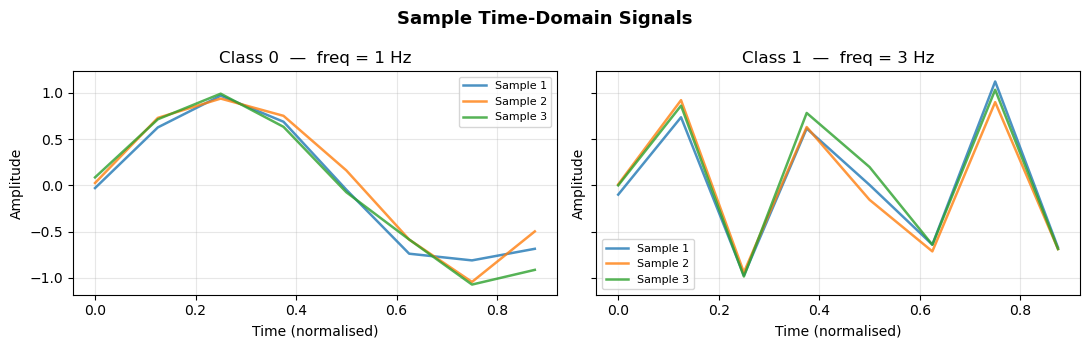

In [17]:
plot_sample_signals(X, y, CLASS_FREQUENCIES, save=False, show=True)

## 2. Classical FFT Pipeline

The FFT decomposes each signal into its frequency components. The magnitude spectrum is used as a feature vector.

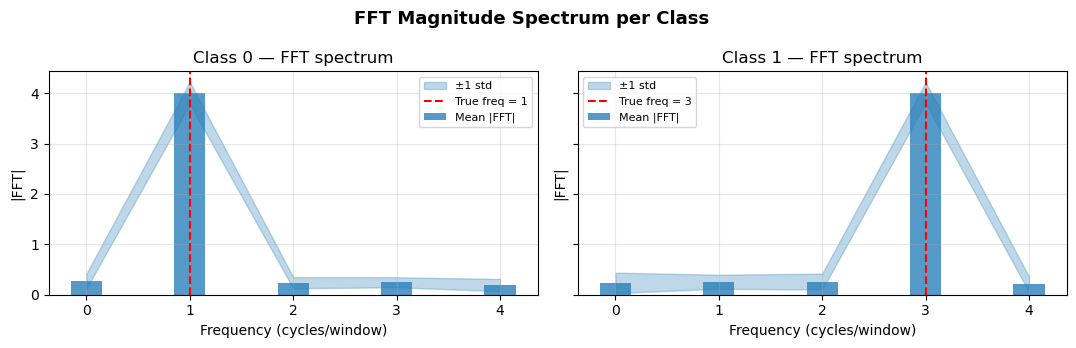

In [18]:
plot_fft_spectrum(X, y, CLASS_FREQUENCIES, save=False, show=True)

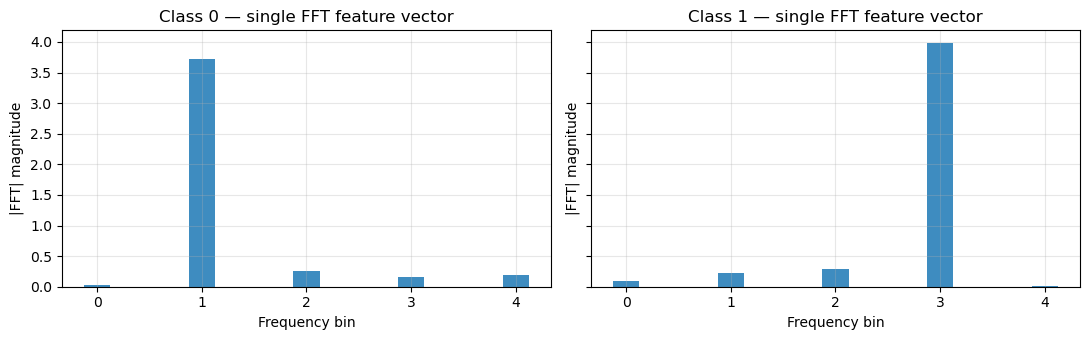

In [20]:
# Inspect raw FFT features for one example from each class
fft_feats = extract_fft_features(X)

fig, axes = plt.subplots(1, 2, figsize=(11, 3.5), sharey=True)
for cls, ax in enumerate(axes):
    freqs = np.fft.rfftfreq(N_SAMPLES, d=1.0/N_SAMPLES)
    ax.bar(freqs, fft_feats[y == cls][0], width=0.25, color='#2980b9', alpha=0.9)
    ax.set_title(f'Class {cls} — single FFT feature vector')
    ax.set_xlabel('Frequency bin')
    ax.set_ylabel('|FFT| magnitude')
    ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [21]:
# Run the full classical pipeline
res_time = run_classical(X, y, feature_mode='time',    verbose=True)
res_fft  = run_classical(X, y, feature_mode='fft_mag', verbose=True)
res_fft_cplx = run_classical(X, y, feature_mode='fft_complex', verbose=True)


  Classical Pipeline  [TIME]
              precision    recall  f1-score   support

     Class 0       1.00      1.00      1.00        13
     Class 1       1.00      1.00      1.00        12

    accuracy                           1.00        25
   macro avg       1.00      1.00      1.00        25
weighted avg       1.00      1.00      1.00        25

  Accuracy : 1.0000
  Precision: 1.0000

  Classical Pipeline  [FFT_MAG]
              precision    recall  f1-score   support

     Class 0       1.00      1.00      1.00        13
     Class 1       1.00      1.00      1.00        12

    accuracy                           1.00        25
   macro avg       1.00      1.00      1.00        25
weighted avg       1.00      1.00      1.00        25

  Accuracy : 1.0000
  Precision: 1.0000

  Classical Pipeline  [FFT_COMPLEX]
              precision    recall  f1-score   support

     Class 0       1.00      1.00      1.00        13
     Class 1       1.00      1.00      1.00        12

  

## 3. Quantum QFT Pipeline

Each signal is amplitude-encoded into an `n`-qubit state, the QFT circuit is applied, then the measurement probability distribution is used as the feature vector.

### 3a. Inspect the QFT Circuit

In [22]:
example_signal = X[0]
qc = build_qft_circuit(example_signal)
print(f'Circuit qubits  : {qc.num_qubits}')
print(f'Circuit depth   : {qc.depth()}')
qc.decompose(reps=1).draw('text', fold=40)

Circuit qubits  : 3
Circuit depth   : 3


»
q_0: ─|0>─»
          »
q_1: ─|0>─»
          »
q_2: ─|0>─»
          »
c: 3/═════»
          »
«     ┌──────────────────────────────────────────────────────────────────────────────────────────┐»
«q_0: ┤0                                                                                         ├»
«     │                                                                                          │»
«q_1: ┤1 State Preparation(-0.015943,0.33555,0.51939,0.36829,-0.025378,-0.39604,-0.4348,-0.3677) ├»
«     │                                                                                          │»
«q_2: ┤2                                                                                         ├»
«     └──────────────────────────────────────────────────────────────────────────────────────────┘»
«c: 3/════════════════════════════════════════════════════════════════════════════════════════════»
«                                                                                                 »
«     ┌──────┐┌─┐      
«q_0: ┤0     ├┤M├──────
«     │      │└╥┘┌─┐   
«q_1: ┤1 QFT ├─╫─┤M├───
«     │      │ ║ └╥┘┌─┐
«q_2: ┤2     ├─╫──╫─┤M├
«     └──────┘ ║  ║ └╥┘
«c: 3/═════════╩══╩══╩═
«              0  1  2

### 3b. Extract QFT Features

In [23]:
# This cell simulates quantum circuits over many shots
qft_feats = extract_qft_features(X, shots=SHOTS, verbose=True)
print(f'QFT features shape: {qft_feats.shape}')

  Encoding signal 1/100 …
  Encoding signal 11/100 …
  Encoding signal 21/100 …
  Encoding signal 31/100 …
  Encoding signal 41/100 …
  Encoding signal 51/100 …
  Encoding signal 61/100 …
  Encoding signal 71/100 …
  Encoding signal 81/100 …
  Encoding signal 91/100 …
QFT features shape: (100, 8)


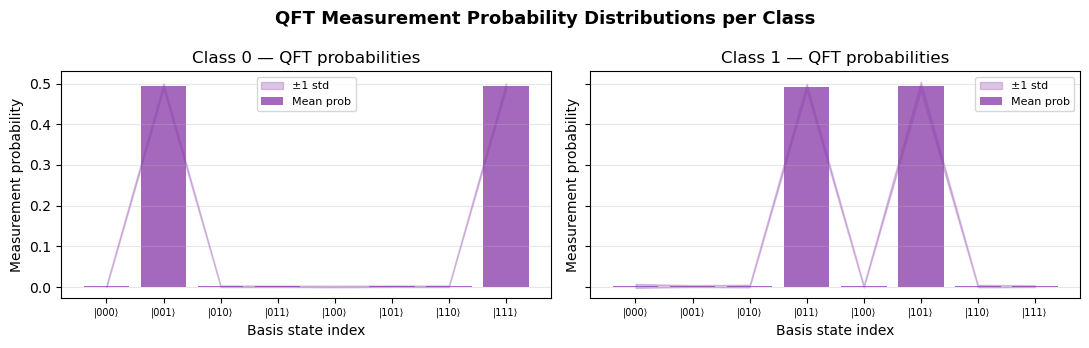

In [24]:
plot_qft_probabilities(qft_feats, y, save=False, show=True)

In [25]:
# Run the full quantum pipeline
res_qft = run_quantum(X, y, shots=SHOTS, verbose=True)


  Extracting QFT features …
  Encoding signal 1/100 …
  Encoding signal 11/100 …
  Encoding signal 21/100 …
  Encoding signal 31/100 …
  Encoding signal 41/100 …
  Encoding signal 51/100 …
  Encoding signal 61/100 …
  Encoding signal 71/100 …
  Encoding signal 81/100 …
  Encoding signal 91/100 …

  Quantum Pipeline  [QFT | shots=4096]
              precision    recall  f1-score   support

     Class 0       1.00      1.00      1.00        13
     Class 1       1.00      1.00      1.00        12

    accuracy                           1.00        25
   macro avg       1.00      1.00      1.00        25
weighted avg       1.00      1.00      1.00        25

  Accuracy : 1.0000
  Precision: 1.0000


## 4. Transform Comparison — What Information Do We Actually Get?

This section directly addresses a fundamental asymmetry between the two transforms:

| | FFT | QFT + Measurement |
|---|---|---|
| Output type | Complex amplitudes | Probability distribution |
| Magnitude | ✓ Directly accessible | ✓ Encoded in probabilities |
| **Phase** | **✓ Directly accessible** | **✗ Destroyed on measurement** |
| Deterministic? | Yes | No — probabilistic |

The FFT returns complex values `X[k] = |X[k]| · e^(i·φ[k])` where both magnitude
and phase `φ[k]` are available. When we **measure** the QFT output, the quantum state
collapses to a basis state with probability `|amplitude|²` — the phase information
is irreversibly lost. This means the QFT pipeline is working with **strictly less
information** than even the `fft_mag` pipeline, let alone `fft_complex`.

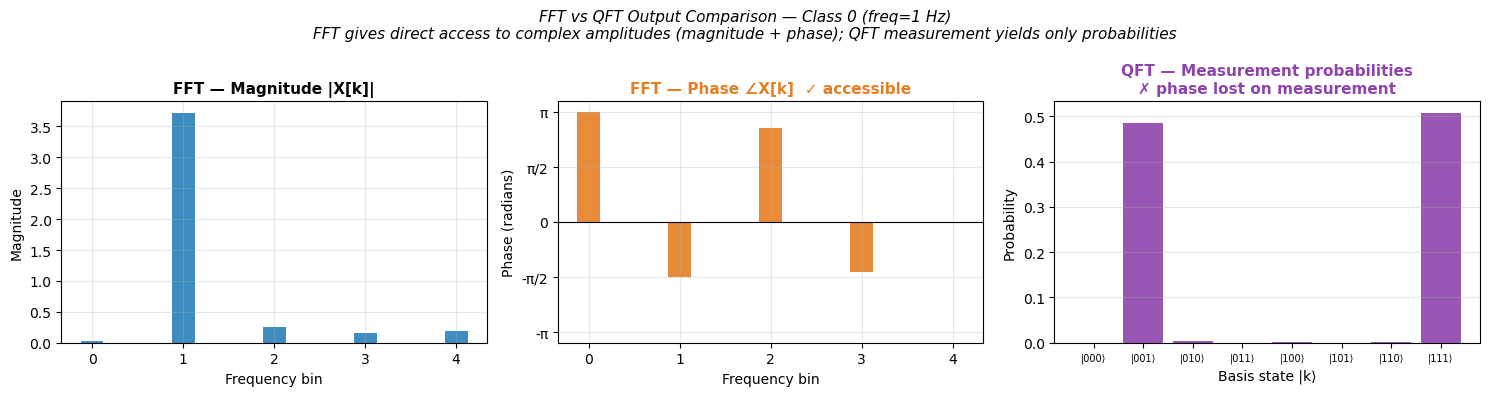

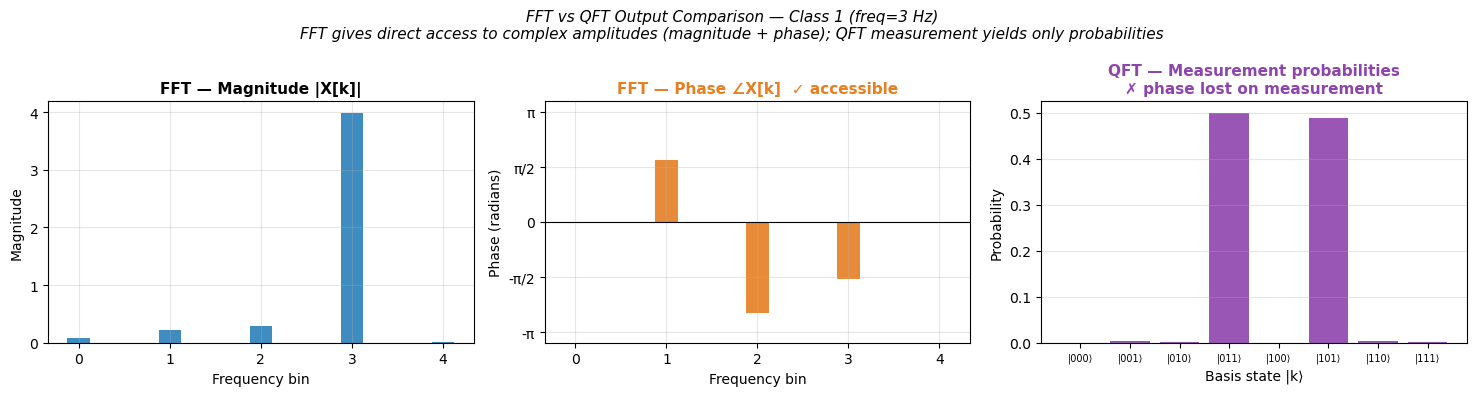

In [26]:
# Side-by-side plot: FFT magnitude, FFT phase, QFT probabilities for one signal per class
for cls in [0, 1]:
    sig      = X[y == cls][0]
    qft_prob = qft_feats[y == cls][0]
    plot_transform_comparison(
        sig, qft_prob,
        label=f'Class {cls} (freq={CLASS_FREQUENCIES[cls]} Hz)',
        save=False, show=True
    )

In [27]:
# Quantify the information difference explicitly
fft_mag_feats     = extract_fft_features(X, mode='fft_mag')
fft_complex_feats = extract_fft_features(X, mode='fft_complex')

print('Feature vector sizes per signal:')
print(f'  Time domain       : {X.shape[1]} values  (real)')
print(f'  FFT magnitude     : {fft_mag_feats.shape[1]} values  (real, magnitude only)')
print(f'  FFT complex       : {fft_complex_feats.shape[1]} values  (real + imaginary — full phase info)')
print(f'  QFT probabilities : {qft_feats.shape[1]} values  (real, non-negative, sums to 1)')
print()
print('Phase information present?')
print(f'  FFT imaginary parts (phase-encoded): {fft_complex_feats[0, fft_mag_feats.shape[1]:]}')
print(f'  QFT probs (no phase) — sum = {qft_feats[0].sum():.4f}, all >= 0: {(qft_feats[0] >= 0).all()}')

Feature vector sizes per signal:
  Time domain       : 8 values  (real)
  FFT magnitude     : 5 values  (real, magnitude only)
  FFT complex       : 10 values  (real + imaginary — full phase info)
  QFT probabilities : 8 values  (real, non-negative, sums to 1)

Phase information present?
  FFT imaginary parts (phase-encoded): [ 0.         -3.72299013  0.11415813 -0.156148    0.        ]
  QFT probs (no phase) — sum = 1.0000, all >= 0: True


## 5. Head-to-Head Comparison

In [28]:
# Attach full metrics to each result dict
res_time.update(evaluate(res_time['y_test'], res_time['y_pred'], 'classical_time'))
res_fft.update( evaluate(res_fft['y_test'],  res_fft['y_pred'],  'classical_fft_mag'))
res_qft.update( evaluate(res_qft['y_test'],  res_qft['y_pred'],  'quantum_qft'))

all_results = [res_time, res_fft, res_qft]
compare_results(all_results)


----------------------------------------------------------------------
  PIPELINE COMPARISON
----------------------------------------------------------------------
Pipeline                  accuracy   precision      recall          f1
----------------------------------------------------------------------
classical_time              1.0000      1.0000      1.0000      1.0000
classical_fft_mag           1.0000      1.0000      1.0000      1.0000
quantum_qft                 1.0000      1.0000      1.0000      1.0000
----------------------------------------------------------------------

  Best accuracy → classical_time  (1.0000)



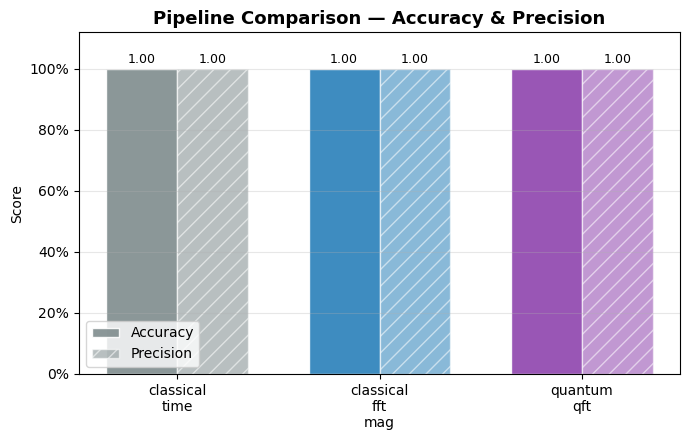

In [29]:
plot_accuracy_bar(all_results, save=False, show=True)

## 6. Noise Robustness Sweep

Re-run all pipelines at increasing noise levels to see how each degrades.

In [30]:
noise_levels = [0.0, 0.05, 0.1, 0.2, 0.4, 0.8]
results_by_noise = {}

for std in noise_levels:
    print(f'  noise_std = {std:.2f}  ...', end=' ')
    Xn, yn = generate_dataset(n_per_class=N_PER_CLASS, noise_std=std)

    rt = run_classical(Xn, yn, feature_mode='time',    verbose=False)
    rf = run_classical(Xn, yn, feature_mode='fft_mag', verbose=False)
    rq = run_quantum(Xn, yn, shots=SHOTS, verbose=False)

    rt.update(evaluate(rt['y_test'], rt['y_pred'], 'classical_time'))
    rf.update(evaluate(rf['y_test'], rf['y_pred'], 'classical_fft_mag'))
    rq.update(evaluate(rq['y_test'], rq['y_pred'], 'quantum_qft'))

    results_by_noise[std] = [rt, rf, rq]
    print('done')

print('Sweep complete.')

  noise_std = 0.00  ... 

done
  noise_std = 0.05  ... done
  noise_std = 0.10  ... done
  noise_std = 0.20  ... done
  noise_std = 0.40  ... done
  noise_std = 0.80  ... done
Sweep complete.


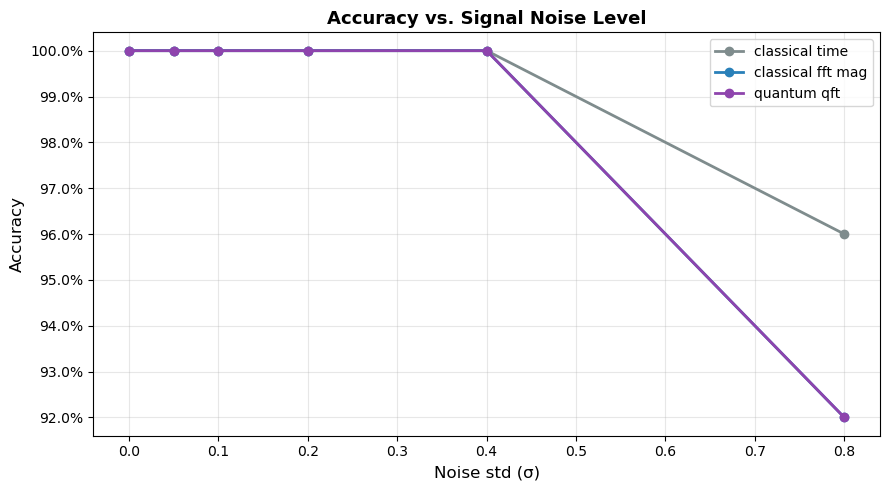

In [31]:
plot_noise_sweep(noise_levels, results_by_noise, save=False, show=True)